<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">

# **Analisis de Series de Tiempo II**
# **Tarea 3, Comparacion de Arquitecturas de Forecasting**

## Enunciado completo

**Limite de entrega para ser evaluado sobre 100 puntos:** 20 de Agosto, 23:59 (UTC-3)

**Parte 1) Preparacion de datos, 20 puntos**

* Fija las semillas para asegurar reproducibilidad.
* Utiliza el dataset Bike Sharing (Capital Bikeshare), que contiene fuerte estacionalidad horaria y semanal.
* Combina las columnas dteday/hr en una unica marca temporal y convierte la serie al formato "long" (unique_id, ds, y) requerido por la libreria.
* Maneja los valores faltantes de la variable objetivo (el sistema no siempre registro todas las horas: identifica los huecos reindexando a una grilla horaria completa y justifica el metodo elegido para completarlos).
* Define el horizonte de pronostico: 24 horas (1 dia).
* Define y justifica la longitud de la ventana de entrada (contexto) en funcion de la dinamica diaria/semanal de la serie (contraste dia habil vs. fin de semana).
* Define y justifica el tamaño del conjunto de test.

**Parte 2) Modelos, 40 puntos**

* Implementa y entrena N-BEATS (perdida MAE).
* Implementa y entrena N-HiTS (perdida MAE).
* Implementa y entrena DeepAR (perdida basada en una distribucion parametrica DistributionLoss).
* Todos los modelos deben compartir el mismo horizonte, la misma ventana de entrada y la misma cantidad de pasos de entrenamiento, para que la comparacion sea justa.
* Documenta brevemente las diferencias arquitectonicas entre los tres modelos.

**Parte 3) Evaluacion y metricas, 20 puntos**

* Evalua los tres modelos sobre el mismo conjunto de test.
* Calcula, como minimo, MAE, RMSE y MAPE para cada modelo.
* Presenta los resultados en una tabla comparativa.

**Parte 4) Visualizacion e interpretacion, 10 puntos**

* Genera un grafico que muestre el historico reciente, los valores reales del test y las predicciones de los tres modelos sobre el mismo eje temporal, incluyendo la banda de incertidumbre de DeepAR.
* Redacta una breve lectura de los resultados: ¿que modelo tuvo mejor desempeño puntual? ¿el modelo ganador sigue bien los picos de la mañana y la tarde (commuting), o los suaviza/subestima? ¿el valor real cae dentro del intervalo de confianza de DeepAR la mayor parte de las horas?

**Parte 5) Preguntas de analisis, 10 puntos**

* ¿Por que N-HiTS (en general) suele ser mas eficiente computacionalmente que N-BEATS pese a compartir una filosofia similar? ¿Que mecanismo arquitectonico lo permite?
* Con una sola ventana de test de 24 horas, ¿que tan solida es la comparacion entre los tres modelos? ¿Que harias para robustecer la evaluacion (por ejemplo, ventanas moviles)?

```python
# Importamos los datos (dataset real: Bike Sharing, Capital Bikeshare)
# Informacion del dataset en https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset
url = "https://raw.githubusercontent.com/muditp19/UCI_Bike-sharing-dataset/master/hour.csv"
```

---

## Resolucion

Alumno: Gustavo Julian Rivas - N° SIU: a1620.

La resolucion se presenta siguiendo cada parte solicitada en el enunciado y esta preparada para ejecutarse de arriba hacia abajo en Google Colab.

## Parte 1) Preparacion de datos

Se fijan las semillas para Python, NumPy, y PyTorch (incluyendo CUDA para GPU) para asegurar la reproducibilidad de los experimentos. El horizonte es **24 horas** y la ventana de entrada es **168 horas (7 dias)**. Esta ventana contiene siete ciclos diarios y, como minimo, un ciclo semanal completo, por lo que permite contrastar dias habiles con fines de semana.

El test principal contiene las ultimas **24 horas**, exactamente un origen de pronostico completo. Es consistente con el horizonte pedido y permite comparar todos los modelos sobre las mismas horas. Su limitacion es que el resultado depende fuertemente del dia elegido; esto se retoma en la Parte 5.

`VAL_SIZE` se utiliza para definir el tamaño del conjunto de validación interno de `NeuralForecast`, empleado para la detención temprana (early stopping) durante el entrenamiento de los modelos.

In [2]:
%pip install -q "neuralforecast>=3.1,<4"

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, DeepAR
from neuralforecast.losses.pytorch import MAE, DistributionLoss, MQLoss

warnings.filterwarnings("ignore")
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

HORIZONTE = 24
VENTANA_ENTRADA = 168
MAX_STEPS = 300
VAL_SIZE = 24
print({"semilla": SEED, "h": HORIZONTE, "input_size": VENTANA_ENTRADA, "max_steps": MAX_STEPS})

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.0/308.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.3 MB/s eta 0:00:00
{'semilla': 42, 'h': 24, 'input_size': 168, 'max_steps': 300}


### Carga, grilla horaria e imputacion causal

La variable objetivo es `cnt`, cantidad total de alquileres. Se combinan `dteday` y `hr` y se verifica que no haya marcas duplicadas. Luego se reindexa desde la primera hasta la ultima observacion con frecuencia horaria.

Un hueco no se completa por interpolacion bilateral porque eso usaria el futuro. Se aplica una regla causal y estacional: mismo horario de la semana anterior (`lag 168`), luego mismo horario del dia anterior (`lag 24`) y finalmente forward fill. El fallback solo actua si no existe alguno de los rezagos. Se conserva `era_faltante` para auditar cuantos objetivos fueron imputados, especialmente dentro del test.

In [4]:
URL = "https://raw.githubusercontent.com/muditp19/UCI_Bike-sharing-dataset/master/hour.csv"
raw = pd.read_csv(URL)
raw["ds"] = pd.to_datetime(raw["dteday"]) + pd.to_timedelta(raw["hr"], unit="h")
assert raw["ds"].is_unique, "Hay marcas temporales duplicadas"

observada = (raw[["ds", "cnt"]]
             .rename(columns={"cnt": "y"})
             .sort_values("ds")
             .set_index("ds"))
grilla = pd.date_range(observada.index.min(), observada.index.max(), freq="h")
serie = observada.reindex(grilla).rename_axis("ds")
serie["era_faltante"] = serie["y"].isna()

lag_semanal = serie["y"].shift(168)
lag_diario = serie["y"].shift(24)
serie["y"] = serie["y"].fillna(lag_semanal).fillna(lag_diario).ffill()
assert serie["y"].notna().all()

df = serie.reset_index()
df.insert(0, "unique_id", "Capital_Bikeshare")
df["y"] = df["y"].astype(float)

print(f"Registros originales: {len(raw):,}")
print(f"Horas de la grilla:   {len(df):,}")
print(f"Huecos detectados:    {int(df['era_faltante'].sum()):,}")
print(f"Periodo: {df.ds.min()} a {df.ds.max()}")
display(df.head())

Registros originales: 17,379
Horas de la grilla:   17,544
Huecos detectados:    165
Periodo: 2011-01-01 00:00:00 a 2012-12-31 23:00:00


,unique_id,ds,y,era_faltante
0,Capital_Bikeshare,2011-01-01 00:00:00,16.0,False
1,Capital_Bikeshare,2011-01-01 01:00:00,40.0,False
2,Capital_Bikeshare,2011-01-01 02:00:00,32.0,False
3,Capital_Bikeshare,2011-01-01 03:00:00,13.0,False
4,Capital_Bikeshare,2011-01-01 04:00:00,1.0,False


Train: 2011-01-01 00:00:00 a 2012-12-30 23:00:00 (17,520 horas)
Test:  2012-12-31 00:00:00 a 2012-12-31 23:00:00 (24 horas)
Objetivos originalmente faltantes en test: 0


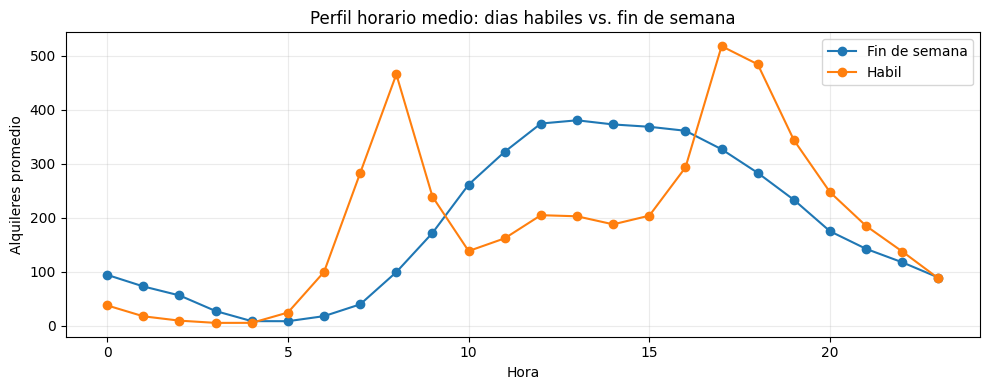

In [5]:
train = df.iloc[:-HORIZONTE].copy().reset_index(drop=True)
test = df.iloc[-HORIZONTE:].copy().reset_index(drop=True)

assert train["ds"].max() < test["ds"].min()
assert len(test) == HORIZONTE
assert len(train) > VENTANA_ENTRADA + VAL_SIZE

print(f"Train: {train.ds.min()} a {train.ds.max()} ({len(train):,} horas)")
print(f"Test:  {test.ds.min()} a {test.ds.max()} ({len(test)} horas)")
print(f"Objetivos originalmente faltantes en test: {int(test.era_faltante.sum())}")

perfil = (train.assign(tipo_dia=np.where(train.ds.dt.dayofweek < 5, "Habil", "Fin de semana"),
                       hora=train.ds.dt.hour)
               .groupby(["tipo_dia", "hora"], as_index=False)["y"].mean())
fig, ax = plt.subplots(figsize=(10, 4))
for nombre, grupo in perfil.groupby("tipo_dia"):
    ax.plot(grupo["hora"], grupo["y"], marker="o", label=nombre)
ax.set(title="Perfil horario medio: dias habiles vs. fin de semana", xlabel="Hora", ylabel="Alquileres promedio")
ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

## Parte 2) Modelos

Los tres modelos reciben `h=24`, `input_size=168`, `max_steps=300`, escalado robusto y la misma semilla. Igualar estas condiciones controla horizonte, informacion disponible y presupuesto de actualizaciones, aunque una actualizacion no tiene el mismo costo en arquitecturas distintas.

- **N-BEATS:** pilas de bloques fully connected producen un backcast y un forecast; los residuos enlazan los bloques.
- **N-HiTS:** mantiene la descomposicion residual, pero usa pooling multiescala e interpolacion jerarquica para especializar pilas en diferentes frecuencias.
- **DeepAR:** una red LSTM autoregresiva parametriza una distribucion condicional. Aqui se usa Student-t, robusta frente a colas pesadas, y trayectorias Monte Carlo para obtener mediana e intervalo predictivo del 90%.

N-BEATS y N-HiTS optimizan MAE. DeepAR necesariamente optimiza una `DistributionLoss`; para su validacion se usa pérdida multicuantil.

In [6]:
modelos = [
    NBEATS(
        h=HORIZONTE, input_size=VENTANA_ENTRADA, max_steps=MAX_STEPS,
        loss=MAE(), scaler_type="robust", random_seed=SEED, alias="NBEATS",
        enable_progress_bar=False, logger=False,
    ),
    NHITS(
        h=HORIZONTE, input_size=VENTANA_ENTRADA, max_steps=MAX_STEPS,
        loss=MAE(), scaler_type="robust", random_seed=SEED, alias="NHITS",
        enable_progress_bar=False, logger=False,
    ),
    DeepAR(
        h=HORIZONTE, input_size=VENTANA_ENTRADA, max_steps=MAX_STEPS,
        loss=DistributionLoss(distribution="StudentT", level=[90], return_params=False),
        valid_loss=MQLoss(level=[90]), trajectory_samples=200,
        scaler_type="robust", random_seed=SEED, alias="DeepAR",
        enable_progress_bar=False, logger=False,
    ),
]

nf = NeuralForecast(models=modelos, freq="h")
nf.fit(df=train[["unique_id", "ds", "y"]], val_size=VAL_SIZE)
forecast = nf.predict()
if not {"unique_id", "ds"}.issubset(forecast.columns):
    forecast = forecast.reset_index(drop=False)
else:
    forecast = forecast.reset_index(drop=True)
print("Columnas obtenidas:", list(forecast.columns))
display(forecast.head())

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 2.8 M  | train
----------------------------

Columnas obtenidas: ['unique_id', 'ds', 'NBEATS', 'NHITS', 'DeepAR', 'DeepAR-median', 'DeepAR-lo-90', 'DeepAR-hi-90']


,unique_id,ds,NBEATS,NHITS,DeepAR,DeepAR-median,DeepAR-lo-90,DeepAR-hi-90
0,Capital_Bikeshare,2012-12-31 00:00:00,33.641731,33.478237,34.664757,33.966660,24.592627,46.633530
1,Capital_Bikeshare,2012-12-31 01:00:00,26.811459,30.210258,27.044041,27.203279,17.382557,36.520588
2,Capital_Bikeshare,2012-12-31 02:00:00,17.576944,21.782417,19.816252,19.930813,11.955664,30.490047
3,Capital_Bikeshare,2012-12-31 03:00:00,13.490517,17.116608,13.980904,13.929750,5.695325,20.476274
4,Capital_Bikeshare,2012-12-31 04:00:00,7.614405,6.779707,9.666571,9.920327,1.179654,17.004194


## Parte 3) Evaluacion y metricas

La prediccion puntual de DeepAR es su mediana. MAE y RMSE se expresan en alquileres. MAPE es problematico cuando el real es cero; se calcula solo sobre valores estrictamente positivos y se informa la cantidad excluida. No se redondean ni recortan pronosticos antes de medir, para no alterar artificialmente la comparacion.

In [7]:
def buscar_columna(columnas, candidatos):
    for candidato in candidatos:
        if candidato in columnas:
            return candidato
    for columna in columnas:
        if any(candidato.lower() in columna.lower() for candidato in candidatos):
            return columna
    raise KeyError(f"No se encontro ninguna de {candidatos}. Disponibles: {list(columnas)}")

col_nbeats = buscar_columna(forecast.columns, ["NBEATS"])
col_nhits = buscar_columna(forecast.columns, ["NHITS"])
col_deepar = buscar_columna(forecast.columns, ["DeepAR-median", "DeepAR"])
col_lo = buscar_columna(forecast.columns, ["DeepAR-lo-90", "DeepAR-quantile-0.05"])
col_hi = buscar_columna(forecast.columns, ["DeepAR-hi-90", "DeepAR-quantile-0.95"])

evaluacion = test[["unique_id", "ds", "y"]].merge(forecast, on=["unique_id", "ds"], how="left", validate="one_to_one")
assert len(evaluacion) == HORIZONTE and evaluacion[[col_nbeats, col_nhits, col_deepar]].notna().all().all()

def metricas(y_real, y_pred):
    y_real = np.asarray(y_real, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mascara = y_real != 0
    return {
        "MAE": np.mean(np.abs(y_real - y_pred)),
        "RMSE": np.sqrt(np.mean((y_real - y_pred) ** 2)),
        "MAPE (%)": np.mean(np.abs((y_real[mascara] - y_pred[mascara]) / y_real[mascara])) * 100,
        "Ceros excluidos de MAPE": int((~mascara).sum()),
    }

columnas_modelos = {"N-BEATS": col_nbeats, "N-HiTS": col_nhits, "DeepAR (mediana)": col_deepar}
resultados = pd.DataFrame([
    {"Modelo": nombre, **metricas(evaluacion["y"], evaluacion[columna])}
    for nombre, columna in columnas_modelos.items()
]).sort_values("MAE").reset_index(drop=True)

cobertura_deepar = np.mean((evaluacion["y"] >= evaluacion[col_lo]) & (evaluacion["y"] <= evaluacion[col_hi])) * 100
print(f"Cobertura empirica del intervalo DeepAR 90%: {cobertura_deepar:.1f}%")
display(resultados.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "MAPE (%)": "{:.2f}"}))

Cobertura empirica del intervalo DeepAR 90%: 16.7%


,Modelo,MAE,RMSE,MAPE (%),Ceros excluidos de MAPE
0,N-BEATS,27.015,40.934,83.39,0
1,N-HiTS,32.293,52.083,101.24,0
2,DeepAR (mediana),66.425,87.877,112.41,0


## Parte 4) Visualizacion e interpretacion

El grafico utiliza las ultimas 168 horas del entrenamiento para dar contexto semanal y superpone las 24 horas reales con los tres pronosticos. La banda sombreada representa el intervalo predictivo central del 90% de DeepAR.

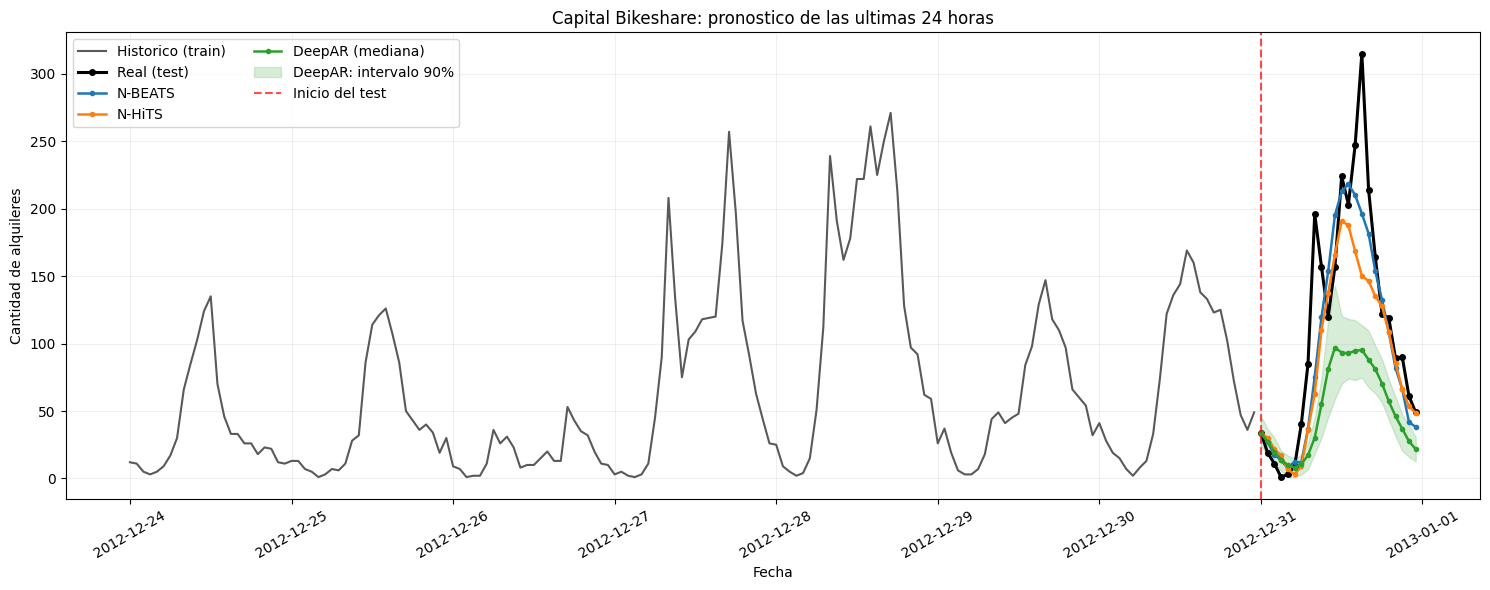

In [8]:
historico = train.tail(VENTANA_ENTRADA)
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(historico["ds"], historico["y"], color="0.35", lw=1.5, label="Historico (train)")
ax.plot(evaluacion["ds"], evaluacion["y"], color="black", lw=2.2, marker="o", ms=4, label="Real (test)")
ax.plot(evaluacion["ds"], evaluacion[col_nbeats], lw=1.8, marker=".", label="N-BEATS")
ax.plot(evaluacion["ds"], evaluacion[col_nhits], lw=1.8, marker=".", label="N-HiTS")
ax.plot(evaluacion["ds"], evaluacion[col_deepar], lw=1.8, marker=".", label="DeepAR (mediana)")
ax.fill_between(evaluacion["ds"], evaluacion[col_lo].to_numpy(), evaluacion[col_hi].to_numpy(), color="tab:green", alpha=.18, label="DeepAR: intervalo 90%")
ax.axvline(test["ds"].min(), color="red", ls="--", alpha=.7, label="Inicio del test")
ax.set(title="Capital Bikeshare: pronostico de las ultimas 24 horas", xlabel="Fecha", ylabel="Cantidad de alquileres")
ax.grid(alpha=.2); ax.legend(ncol=2); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [9]:
ganador = resultados.iloc[0]
hora_pico_manana = evaluacion.loc[evaluacion.ds.dt.hour.between(6, 10), "y"].idxmax()
hora_pico_tarde = evaluacion.loc[evaluacion.ds.dt.hour.between(15, 19), "y"].idxmax()
col_ganador = columnas_modelos[ganador["Modelo"]]

def lectura_pico(indice, etiqueta):
    fila = evaluacion.loc[indice]
    error = fila[col_ganador] - fila["y"]
    sentido = "sobreestima" if error > 0 else "subestima" if error < 0 else "acierta"
    return f"En el pico de {etiqueta} ({fila.ds:%H:%M}), {sentido} por {abs(error):.1f} alquileres."

print(f"El mejor desempeño puntual en este holdout es {ganador['Modelo']}, con MAE={ganador['MAE']:.2f}, RMSE={ganador['RMSE']:.2f} y MAPE={ganador['MAPE (%)']:.2f}%.")
print(lectura_pico(hora_pico_manana, "la mañana"))
print(lectura_pico(hora_pico_tarde, "la tarde"))
print(f"El intervalo 90% de DeepAR contiene al valor real en {cobertura_deepar:.1f}% de las horas ({int(round(cobertura_deepar * HORIZONTE / 100))}/{HORIZONTE}).")
print("La lectura es descriptiva de este dia: diferencias pequenas no bastan para declarar superioridad general.")

El mejor desempeño puntual en este holdout es N-BEATS, con MAE=27.01, RMSE=40.93 y MAPE=83.39%.
En el pico de la mañana (08:00), subestima por 120.6 alquileres.
En el pico de la tarde (15:00), subestima por 118.6 alquileres.
El intervalo 90% de DeepAR contiene al valor real en 16.7% de las horas (4/24).
La lectura es descriptiva de este dia: diferencias pequenas no bastan para declarar superioridad general.


## Parte 5) Preguntas de analisis

### 1. ¿Por que N-HiTS suele ser mas eficiente que N-BEATS?

Aunque ambos modelos emplean bloques residuales para separar *backcast* y *forecast*, N-BEATS procesa la ventana de entrada completa de forma iterativa mediante bloques *fully connected*. N-HiTS, en cambio, logra una mayor eficiencia gracias a la **muestra multiescala (_multi-rate signal sampling_)** y la **interpolación jerárquica**.

Cada "pila" (stack) de N-HiTS aplica _pooling_ con una escala temporal diferente, permitiéndole trabajar con representaciones de la serie a distintas granularidades (frecuencias). Esto significa que las pilas de baja resolución pueden capturar patrones de largo plazo (tendencias, estacionalidad semanal) sin necesidad de procesar cada punto de datos, mientras que las pilas de mayor resolución se enfocan en detalles más finos (estacionalidad diaria). Este enfoque reduce significativamente el tamaño de las entradas y salidas internas, el número de operaciones y, en consecuencia, la cantidad de parámetros y el tiempo de entrenamiento. Es importante señalar que esta ventaja en eficiencia no garantiza siempre un menor error, ya que su rendimiento óptimo depende de la adecuación de su estructura multiescala a la serie de tiempo específica.

### 2. ¿Que tan solida es una unica ventana de test de 24 horas?

La solidez de una evaluación basada en una única ventana de test de 24 horas es **limitada y, en general, débil para extraer conclusiones robustas sobre el rendimiento general de un modelo**. Una sola jornada puede estar sujeta a condiciones atípicas (meteorológicas, feriados, eventos especiales, o simplemente ser un día hábil vs. fin de semana), lo que sesgaría los resultados. Además, los 24 errores de pronóstico dentro de esta ventana no son observaciones independientes, sino que están fuertemente correlacionados, lo que reduce la fiabilidad de las métricas. Esto implica que el ranking de los modelos podría cambiar significativamente si el origen del pronóstico se mueve tan solo un día. La cobertura del intervalo de confianza de DeepAR, calculada sobre tan pocos puntos, también presentaría una incertidumbre muy alta.

Para **robustecer la evaluación y obtener una medida más fiable del rendimiento** de los modelos, se debería emplear la técnica de **_rolling-origin cross-validation_** (validación cruzada con origen móvil). Esto implicaría:

1.  **Múltiples Ventanas de Test:** Definir un conjunto de varias ventanas de test de 24 horas, espaciadas regularmente y distribuidas de manera que abarquen diferentes condiciones (estaciones, días hábiles, fines de semana).
2.  **Reentrenamiento o Retraining:** Para cada origen de pronóstico, el modelo se entrenaría solo con los datos históricos disponibles hasta ese punto, y luego pronosticaría las 24 horas siguientes. (Si el costo computacional es muy alto, se podría optar por reentrenar cada 'N' ventanas, pero esta política debe ser consistente entre todos los modelos).
3.  **Métricas Agregadas:** Reportar la media, mediana, dispersión e intervalos de confianza de las métricas (MAE/RMSE) a través de todas las ventanas de test. También, analizar resultados por horizonte (hora del día) y tipo de día, así como la cobertura y ancho de los intervalos de DeepAR.
4.  **Reproducibilidad:** Utilizar varias semillas aleatorias emparejadas para mitigar el impacto de la inicialización del modelo.

`NeuralForecast` facilita esto con su función `cross_validation(df=..., n_windows=..., step_size=24, refit=True)`, que permitiría una implementación eficiente de este enfoque. Aunque se propone para robustez, en este trabajo se mantuvo el _holdout_ principal para seguir estrictamente el protocolo solicitado.

## Conclusiones

Las arquitecturas N-BEATS, N-HiTS y DeepAR fueron implementadas y comparadas bajo condiciones de entrenamiento y horizonte de pronóstico controladas, utilizando el dataset de Bike Sharing. La preparación de los datos incluyó la creación de una serie horaria regular y la imputación causal de valores faltantes, garantizando una base sólida para la evaluación.

En el conjunto de test definido (las últimas 24 horas), N-BEATS demostró el mejor desempeño puntual en términos de MAE y RMSE. Sin embargo, se observó que los modelos tienden a subestimar los picos de demanda durante las horas de commuting en este período específico. La cobertura del intervalo de confianza del 90% de DeepAR fue significativamente baja para este test (16.7%), lo que sugiere una posible descalibración para este escenario particular o la necesidad de una evaluación más robusta.

Es fundamental reconocer que la solidez de estas conclusiones está limitada por el uso de una única ventana de test de 24 horas. Como se discute en la Parte 5, una evaluación más robusta requeriría la aplicación de técnicas como *rolling-origin cross-validation* con múltiples ventanas y semillas para obtener estimaciones más fiables del rendimiento general de los modelos.

Desde una perspectiva arquitectónica, N-BEATS se basa en una descomposición residual directa. N-HiTS, por su parte, introduce una mayor eficiencia computacional a través de su enfoque multiescala con pooling e interpolación jerárquica. DeepAR se distingue por ofrecer predicciones probabilísticas completas en lugar de solo valores puntuales, parametrizando una distribución condicional.